# Analysis of the Chess Database
Author: Giorgio Gobbin (Matricola: 683071) Course: Distributed Data Analysis and Mining

1. Environment Setup & Data Loading

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arevel/chess-games")

print("Path to dataset files:", path)

100%|██████████| 1.45G/1.45G [01:20<00:00, 19.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arevel/chess-games/versions/1


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("ChessAnalysis").getOrCreate()

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

path = "/root/.cache/kagglehub/datasets/arevel/chess-games/versions/1"
df = spark.read.csv(path, header=True, inferSchema=True)

df = df.withColumn("WhiteElo", col("WhiteElo").cast(IntegerType()))
df = df.withColumn("BlackElo", col("BlackElo").cast(IntegerType()))

print(df.count())
df.printSchema()

6256184
root
 |-- Event: string (nullable = true)
 |-- White: string (nullable = true)
 |-- Black: string (nullable = true)
 |-- Result: string (nullable = true)
 |-- UTCDate: string (nullable = true)
 |-- UTCTime: timestamp (nullable = true)
 |-- WhiteElo: integer (nullable = true)
 |-- BlackElo: integer (nullable = true)
 |-- WhiteRatingDiff: double (nullable = true)
 |-- BlackRatingDiff: double (nullable = true)
 |-- ECO: string (nullable = true)
 |-- Opening: string (nullable = true)
 |-- TimeControl: string (nullable = true)
 |-- Termination: string (nullable = true)
 |-- AN: string (nullable = true)



2. Data Understanding & Quality Assessment

/tmp/ipython-input-2636312172.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


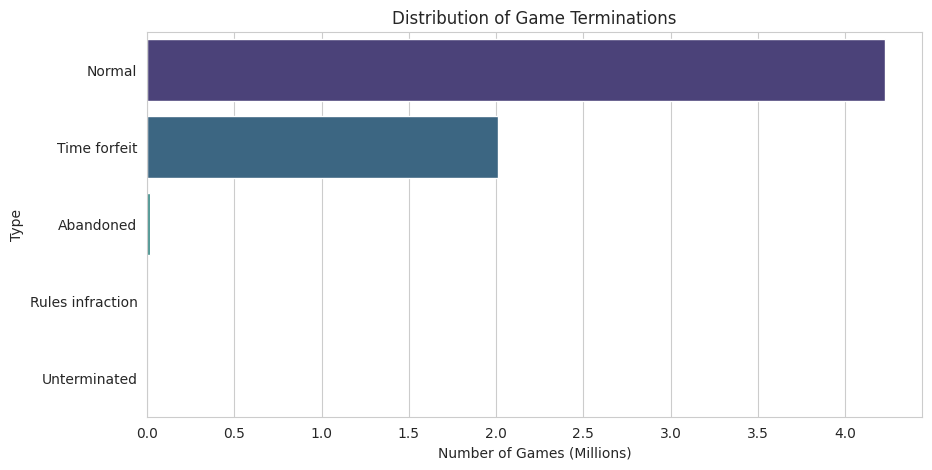

In [5]:
counts = df.groupBy("Termination").count().orderBy("count", ascending=False)
pdf = counts.toPandas()

# Convert to millions
pdf['count'] = pdf['count'] / 1000000

plt.figure(figsize=(10, 5))
sns.barplot(
    x='count',
    y='Termination',
    data=pdf,
    palette='viridis'
)
plt.title('Distribution of Game Terminations')
plt.xlabel('Number of Games (Millions)')
plt.ylabel('Type')
plt.show()

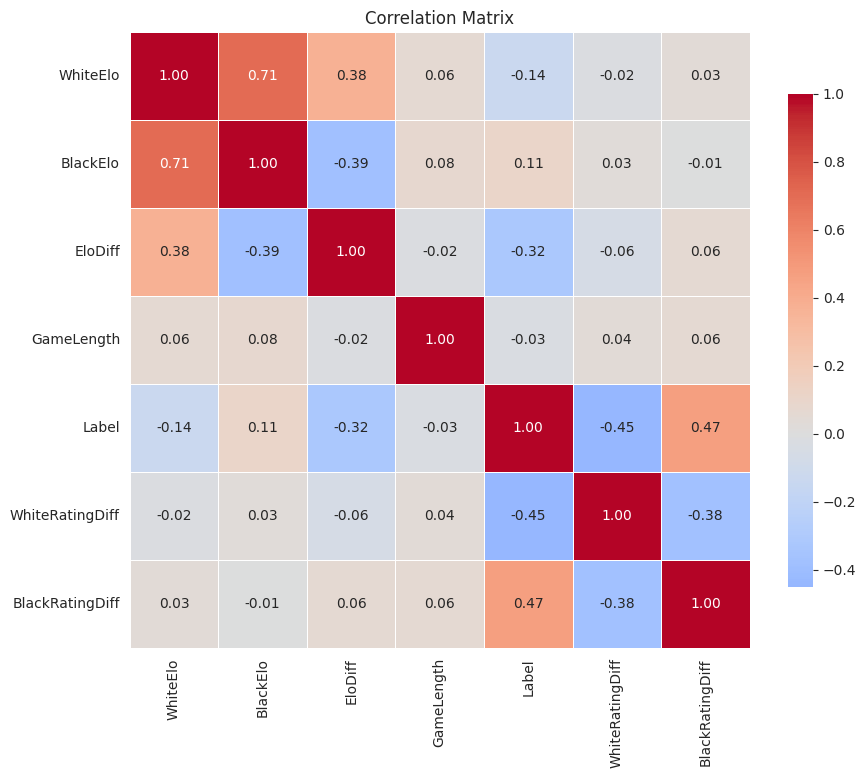

In [7]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col, abs, length, when
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = df.withColumn("WhiteElo", col("WhiteElo").cast("int"))
df = df.withColumn("BlackElo", col("BlackElo").cast("int"))

df = df.withColumn("EloDiff", col("WhiteElo") - col("BlackElo"))
df = df.withColumn("GameLength", length(col("AN")))
df = df.withColumn("Label",
    when(col("Result") == "1-0", 1)
    .when(col("Result") == "0-1", 2)
    .otherwise(0)
)

cols = ["WhiteElo", "BlackElo", "EloDiff", "GameLength", "Label", "WhiteRatingDiff", "BlackRatingDiff"]

assembler = VectorAssembler(inputCols=cols, outputCol="corr_features", handleInvalid="skip")
vector_df = assembler.transform(df).select("corr_features")

matrix = Correlation.corr(vector_df, "corr_features").head()
corr_array = matrix[0].toArray()

pdf = pd.DataFrame(corr_array, index=cols, columns=cols)

plt.figure(figsize=(10, 8))
sns.heatmap(pdf, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix')
plt.show()

+-----+-----+-----+------+-------+-------+--------+--------+---------------+---------------+---+-------+-----------+-----------+---+-------+----------+-----+
|Event|White|Black|Result|UTCDate|UTCTime|WhiteElo|BlackElo|WhiteRatingDiff|BlackRatingDiff|ECO|Opening|TimeControl|Termination| AN|EloDiff|GameLength|Label|
+-----+-----+-----+------+-------+-------+--------+--------+---------------+---------------+---+-------+-----------+-----------+---+-------+----------+-----+
|    0|    0|    0|     0|      0|      0|       0|       0|           4668|           4668|  0|      0|          0|          0|  0|      0|         0|    0|
+-----+-----+-----+------+-------+-------+--------+--------+---------------+---------------+---+-------+-----------+-----------+---+-------+----------+-----+

Total: 6256184, Distinct: 6256183, Duplicates: 1
+-------+------------------+-----------------+
|summary|          WhiteElo|         BlackElo|
+-------+------------------+-----------------+
|  count|          

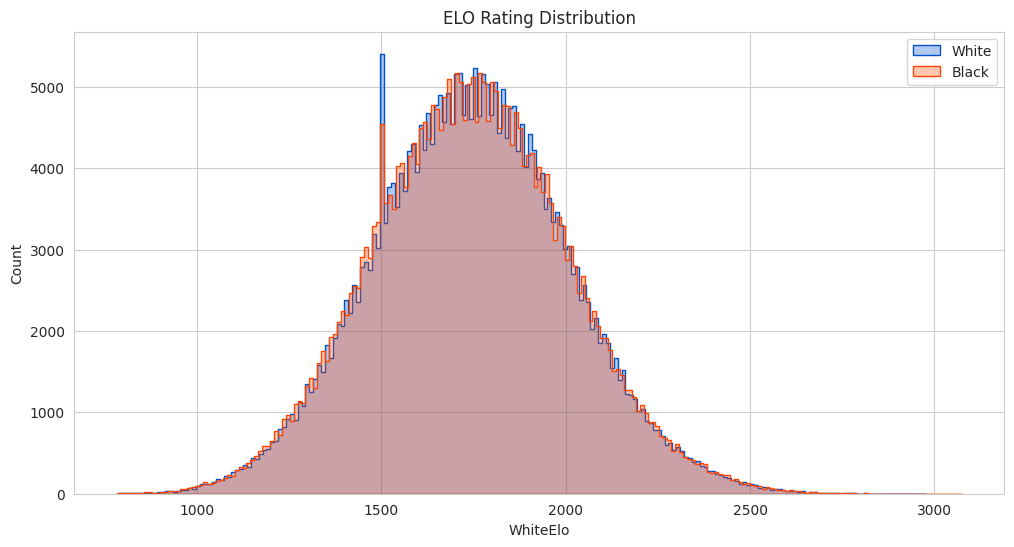

Correlation: 0.7106


In [8]:
from pyspark.sql.functions import isnan, when, count, col

# helper for null check
def count_nulls(c, dtype):
    if dtype in ('double', 'float'):
        return count(when(isnan(c) | col(c).isNull(), c)).alias(c)
    return count(when(col(c).isNull(), c)).alias(c)

df.select([count_nulls(c, t) for c, t in df.dtypes]).show()

# Duplicates check
total = df.count()
distinct = df.distinct().count()
print(f"Total: {total}, Distinct: {distinct}, Duplicates: {total - distinct}")

# Stats
df.select("WhiteElo", "BlackElo").describe().show()

# Cleaning: via duplicati e null
print(f"Righe prima della pulizia: {df.count()}")

df = df.dropDuplicates()
df = df.dropna()

print(f"Righe dopo la pulizia: {df.count()}")

# Plot ELO distribution
sample = df.select("WhiteElo", "BlackElo").sample(fraction=0.05, seed=42).toPandas()

plt.figure(figsize=(12, 6))
sns.histplot(sample['WhiteElo'], color='#0052CC', label='White', element="step", fill=True, alpha=0.3)
sns.histplot(sample['BlackElo'], color='#FF4500', label='Black', element="step", fill=True, alpha=0.3)
plt.title('ELO Rating Distribution')
plt.legend()
plt.show()

corr = df.stat.corr("WhiteElo", "BlackElo")
print(f"Correlation: {corr:.4f}")

3. Data Processing & Feature Engineering

In [9]:
from pyspark.sql.functions import col, when, abs, length, row_number, desc
from pyspark.sql.window import Window

# Filter out abandoned games
df = df.filter(col("Termination") != "Abandoned")

# Create Target Label (1=White, 2=Black, 0=Draw)
df = df.withColumn("Label",
    when(col("Result") == "1-0", 1)
    .when(col("Result") == "0-1", 2)
    .otherwise(0)
)

# Feature Engineering steps
df = df.withColumn("EloDiff", col("WhiteElo") - col("BlackElo"))
df = df.withColumn("EloGap", abs(col("WhiteElo") - col("BlackElo")))
df = df.withColumn("GameLength", length(col("AN")))
df = df.withColumn("AverageElo", (col("WhiteElo") + col("BlackElo")) / 2)

print(f"Rows after processing: {df.count()}")

# Window Function example: Find highest rated game per Opening
spec = Window.partitionBy("ECO").orderBy(desc("WhiteElo"))

df_ranked = df.withColumn("Rank", row_number().over(spec))
top_games = df_ranked.filter(col("Rank") == 1)

top_games.select("ECO", "Opening", "WhiteElo", "Result").show(5, truncate=False)

Rows after processing: 6238226
+---+-------------------------------------------+--------+------+
|ECO|Opening                                    |WhiteElo|Result|
+---+-------------------------------------------+--------+------+
|A00|Van Geet Opening                           |3058    |1-0   |
|A01|Nimzo-Larsen Attack                        |3106    |1-0   |
|A03|Bird Opening: Dutch Variation              |2799    |1-0   |
|A09|Reti Opening                               |2801    |1-0   |
|A11|English Opening: Caro-Kann Defensive System|2683    |1-0   |
+---+-------------------------------------------+--------+------+
only showing top 5 rows
